# 02 — Modelos Base do TCC 1: ARIMA e OLS/MQO

> ⚠️ **Células do modelo ARIMA (busca automática + diagnósticos) e do OLS (regressão + VIF + Shapiro + Breusch-Pagan) são INTOCÁVEIS — conteúdo idêntico ao TCC 1.**

| | |
|---|---|
| **Entradas** | `data/br_transformado.csv` |
| **Saídas** | `data/metricas_comparativo.csv` (linhas ARIMA e OLS) |
| **Ordem** | 2º — após gerar os dados (notebook 01) |


In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy import stats
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [3]:
# Carrega série transformada
br_transformado = load_transformado()
print(f"br_transformado: {br_transformado.shape}")
print(f"Colunas: {br_transformado.columns.tolist()}")
print(f"Período: {br_transformado.index[0].date()} → {br_transformado.index[-1].date()}")


br_transformado: (5598, 7)
Colunas: ['br_ibov_ret_log', 'br_selic_diff', 'br_dolar_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']
Período: 2001-11-07 → 2024-07-30


## Testes de Estacionariedade — `br_transformado`

In [4]:
# ADF e KPSS sobre br_transformado (série já transformada)
# Confirma estacionariedade pós-transformação — resultado reportado na Seção 7.1

def rodar_testes_estacionariedade(df):
    resultados = []
    print("\nTestes de estacionariedade (ADF + KPSS)...")
    for coluna in df.columns:
        try:
            adf   = adfuller(df[coluna].dropna())
            kpss_ = kpss(df[coluna].dropna(), regression='c', nlags='auto')
            resultados.append({
                'Variável':    coluna,
                'P-valor ADF': round(adf[1], 4),
                'P-valor KPSS': round(kpss_[1], 4),
                'ADF (estac.)':  'Sim' if adf[1]   < 0.05 else 'Não',
                'KPSS (estac.)': 'Sim' if kpss_[1] > 0.05 else 'Não',
            })
        except Exception as e:
            resultados.append({'Variável': coluna, 'Erro': str(e)})
    return pd.DataFrame(resultados)

resultados_estacionariedade = rodar_testes_estacionariedade(br_transformado)
display(resultados_estacionariedade)



Testes de estacionariedade (ADF + KPSS)...


C:\Users\Lucao\AppData\Local\Temp\ipykernel_15036\2068593899.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(df[coluna].dropna(), regression='c', nlags='auto')
C:\Users\Lucao\AppData\Local\Temp\ipykernel_15036\2068593899.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(df[coluna].dropna(), regression='c', nlags='auto')
C:\Users\Lucao\AppData\Local\Temp\ipykernel_15036\2068593899.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(df[coluna].dropna(), regression='c', nlags='auto')
C:\Users\Lucao\AppData\Local\Temp\ipykernel_15036\2068593899.py:10: InterpolationWarning: The tes

,Variável,P-valor ADF,P-valor KPSS,ADF (estac.),KPSS (estac.)
0,br_ibov_ret_log,0.0,0.100,Sim,Sim
1,br_selic_diff,0.0,0.100,Sim,Sim
2,br_dolar_diff,0.0,0.100,Sim,Sim
3,br_ipca,0.0,0.055,Sim,Sim
4,br_pib_ret_log,0.0,0.100,Sim,Sim
5,ipca_expectativa_diff,0.0,0.100,Sim,Sim
6,embi_brasil_diff,0.0,0.100,Sim,Sim


#Analise ACF e PACF

In [5]:
# Preparação dos Dados para analise ACF e PACF
alvo_col_name = None
for col in br_transformado.columns:
    if 'ibov' in col and 'ret_log' in col:
        alvo_col_name = col
        break
assert alvo_col_name is not None, "Coluna br_ibov_ret_log nao encontrada em br_transformado"

serie_alvo = br_transformado[alvo_col_name].dropna()

# Serie em nivel (disponivel apenas em modo completo)
if not USE_LOCAL_DATA:
    alvo_col_name2 = None
    for col in df_diario.columns:
        if 'br_ibov' in col:
            alvo_col_name2 = col
            break
    serie_alvo2 = df_diario[alvo_col_name2].dropna()
else:
    serie_alvo2 = None

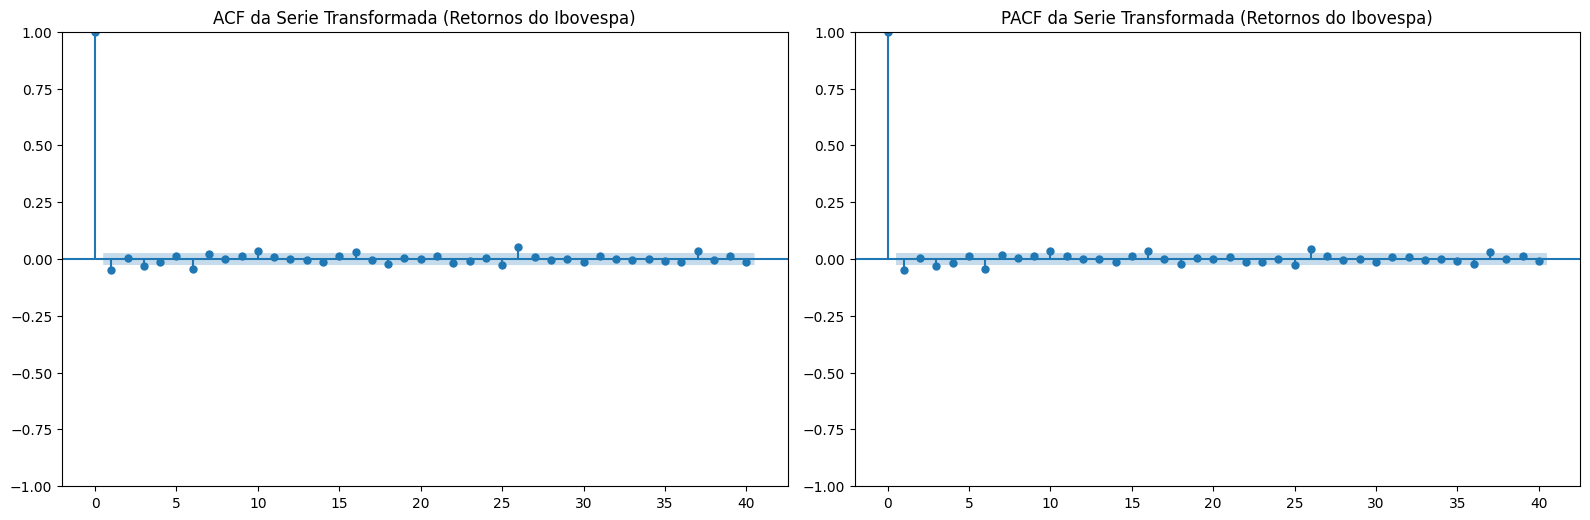

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not USE_LOCAL_DATA and serie_alvo2 is not None:
    plot_acf(serie_alvo2, ax=axes[0, 0], lags=40)
    axes[0, 0].set_title('ACF da Serie Original (Ibovespa em Nivel)')
    plot_pacf(serie_alvo2, ax=axes[0, 1], lags=40)
    axes[0, 1].set_title('PACF da Serie Original (Ibovespa em Nivel)')
else:
    axes[0, 0].set_visible(False)
    axes[0, 1].set_visible(False)

plot_acf(serie_alvo, ax=axes[1, 0], lags=40)
axes[1, 0].set_title('ACF da Serie Transformada (Retornos do Ibovespa)')

plot_pacf(serie_alvo, ax=axes[1, 1], lags=40)
axes[1, 1].set_title('PACF da Serie Transformada (Retornos do Ibovespa)')

plt.tight_layout()
plt.show()

#Modelo ARIMA

In [7]:
# Busca Automática pelo Melhor Modelo ARIMA
# Como o modelo ARIMA(2,0,2) não passou na validação (teste de Ljung-Box),
# vamos automatizar a busca pela melhor combinação (p,q) usando o critério AIC.

# Define os limites para a busca de p e q
p_max = 5
q_max = 5
d = 0 # A série já é estacionária

# Ignora avisos de convergência durante a busca para manter o output limpo
warnings.filterwarnings("ignore")

melhor_aic = float("inf")
melhor_ordem = None
melhor_modelo = None

for p in range(p_max + 1):
    for q in range(q_max + 1):
        if p == 0 and q == 0:
            continue
        try:
            modelo_temp = ARIMA(serie_alvo, order=(p, d, q))
            resultado_temp = modelo_temp.fit()
            if resultado_temp.aic < melhor_aic:
                melhor_aic = resultado_temp.aic
                melhor_ordem = (p, d, q)
                melhor_modelo = resultado_temp
        except Exception:
            continue

# Reativa os avisos
warnings.resetwarnings()

print(f"Melhor ordem: {melhor_ordem} \nAIC: {melhor_aic:.2f}")

Melhor ordem: (4, 0, 3) 
AIC: -29658.05


In [8]:
# Análise do Melhor Modelo
print(melhor_modelo.summary())

                               SARIMAX Results                                
Dep. Variable:        br_ibov_ret_log   No. Observations:                 5598
Model:                 ARIMA(4, 0, 3)   Log Likelihood               14838.024
Date:                Sun, 17 May 2026   AIC                         -29658.048
Time:                        18:38:40   BIC                         -29598.377
Sample:                             0   HQIC                        -29637.254
                               - 5598                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.830      0.067   -2.91e-05       0.001
ar.L1         -0.7292      0.132     -5.517      0.000      -0.988      -0.470
ar.L2          0.0329      0.194      0.170      0.8

In [9]:
# Metricas de avaliacao do modelo ARIMA
y_pred_arima = melhor_modelo.fittedvalues
mae_arima  = mean_absolute_error(serie_alvo, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(serie_alvo, y_pred_arima))

print(f"ARIMA{melhor_ordem} — MAE: {mae_arima:.6f} | RMSE: {rmse_arima:.6f}")

ARIMA(4, 0, 3) — MAE: 0.012225 | RMSE: 0.017085


##Analise de Residuos

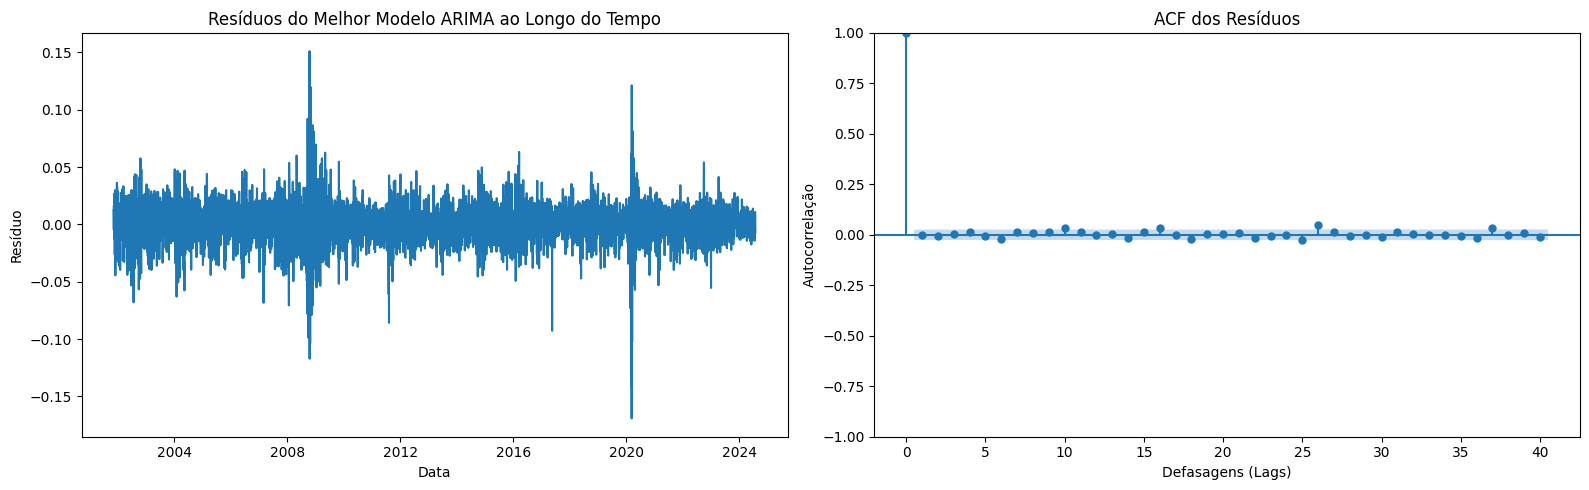

In [10]:
# Validação do Melhor Modelo (Análise dos Resíduos)
residuos = melhor_modelo.resid

# Cria uma figura para os gráficos de validação
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Resíduos ao longo do tempo
axes[0].plot(residuos)
axes[0].set_title('Resíduos do Melhor Modelo ARIMA ao Longo do Tempo')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Resíduo')

# Gráfico 2: Função de Autocorrelação (ACF) dos Resíduos
plot_acf(residuos, ax=axes[1], lags=40, title='ACF dos Resíduos')
axes[1].set_xlabel('Defasagens (Lags)')
axes[1].set_ylabel('Autocorrelação')

plt.tight_layout()
plt.show()

##Teste Ljung-Box

In [11]:
# Teste de Ljung-Box para autocorrelação dos resíduos:
# O objetivo é ter um p-valor (lb_pvalue) > 0.05
lags_teste = min(24, len(residuos)//5)
teste_ljung_box = sm.stats.acorr_ljungbox(residuos, lags=[lags_teste], return_df=True)
display(teste_ljung_box)

,lb_stat,lb_pvalue
24,27.295207,0.290882


#OLS

In [12]:
# Análise de Regressão Linear Múltipla (OLS)

# Preparar as variáveis para o modelo
# Variável Dependente (Y): o que queremos explicar.
y = br_transformado['br_ibov_ret_log']

# Variáveis Independentes (X): os fatores que usaramos para explicar Y.
# Vamos excluir a variável alvo e outras relacionadas ao Ibovespa para evitar redundância.
variaveis_explicativas = [col for col in br_transformado.columns if 'ibov' not in col]
X = br_transformado[variaveis_explicativas]

# É crucial adicionar uma constante (intercepto) ao modelo.
X = sm.add_constant(X)

print(X.columns.tolist())

['const', 'br_selic_diff', 'br_dolar_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']


In [13]:
# Estimação do Modelo OLS
modelo_ols = sm.OLS(y, X)
resultado_ols = modelo_ols.fit()
print(resultado_ols.summary())

                            OLS Regression Results                            
Dep. Variable:        br_ibov_ret_log   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     245.7
Date:                Sun, 17 May 2026   Prob (F-statistic):          1.33e-279
Time:                        18:38:40   Log-Likelihood:                 15478.
No. Observations:                5598   AIC:                        -3.094e+04
Df Residuals:                    5591   BIC:                        -3.090e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.00

In [14]:
# Metricas de avaliacao do modelo OLS
y_pred_ols = resultado_ols.fittedvalues
mae_ols  = mean_absolute_error(y, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y, y_pred_ols))

print(f"OLS — R2: {resultado_ols.rsquared:.4f} | MAE: {mae_ols:.6f} | RMSE: {rmse_ols:.6f}")

OLS — R2: 0.2086 | MAE: 0.011093 | RMSE: 0.015239


##Teste VIF

In [15]:
# Validação dos Pressupostos do Modelo

# Teste de Multicolinearidade (VIF)
# Mede se as variáveis independentes são correlacionadas entre si.
# Valores de VIF acima de 5 ou 10 são geralmente considerados um sinal de alerta.
vif_data = pd.DataFrame()
vif_data["Variável"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data)

,Variável,VIF
0,const,2.821941
1,br_selic_diff,1.009107
2,br_dolar_diff,1.143938
3,br_ipca,1.011920
4,br_pib_ret_log,1.003890
5,ipca_expectativa_diff,1.007590
6,embi_brasil_diff,1.144113


##Teste Shapiro-Wiki

In [16]:
# Teste de Normalidade dos Resíduos (Shapiro-Wilk)
# H0: Os resíduos seguem uma distribuição normal.
# Queremos um p-valor > 0.05 para não rejeitar a normalidade.

residuos = resultado_ols.resid
shapiro_stat, shapiro_p_valor = stats.shapiro(residuos)
print(f"   - Estatística do teste: {shapiro_stat:.4f}")
print(f"   - P-valor: {shapiro_p_valor:.4f}")
if shapiro_p_valor < 0.05:
    print("   - Conclusão: Rejeita-se a hipótese de normalidade dos resíduos (comum em dados financeiros).")
else:
    print("   - Conclusão: Não se rejeita a hipótese de normalidade dos resíduos.")

   - Estatística do teste: 0.9553
   - P-valor: 0.0000
   - Conclusão: Rejeita-se a hipótese de normalidade dos resíduos (comum em dados financeiros).


c:\Users\Lucao\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5598.
  res = hypotest_fun_out(*samples, **kwds)


##Teste Breusch-Pagan

In [17]:
# Teste de Homocedasticidade dos Resíduos (Breusch-Pagan)
# H0: A variância dos resíduos é constante (homocedasticidade).
# Queremos um p-valor > 0.05 para não rejeitar a homocedasticidade.
bp_test = het_breuschpagan(residuos, resultado_ols.model.exog)
labels = ['Estatística LM', 'P-valor LM', 'Estatística F', 'P-valor F']
bp_df = pd.DataFrame(zip(labels, bp_test), columns=['Medida', 'Valor'])
display(bp_df)
if bp_test[1] < 0.05:
    print("   - Conclusão: Rejeita-se a hipótese de homocedasticidade (os erros são heterocedásticos).")
else:
    print("   - Conclusão: Não se rejeita a hipótese de homocedasticidade.")

,Medida,Valor
0,Estatística LM,7.716431e+01
1,P-valor LM,1.374767e-14
2,Estatística F,1.302417e+01
3,P-valor F,1.101182e-14


   - Conclusão: Rejeita-se a hipótese de homocedasticidade (os erros são heterocedásticos).


## Avaliação Out-of-Sample (Split 2020)

In [18]:
# Split treino/teste global
X_all   = br_transformado[[c for c in br_transformado.columns if 'ibov' not in c]]
y_all   = br_transformado[TARGET]

X_train = X_all[X_all.index < DATA_SPLIT_DATE]
X_test  = X_all[X_all.index >= DATA_SPLIT_DATE]
y_train = y_all[y_all.index < DATA_SPLIT_DATE]
y_test  = y_all[y_all.index >= DATA_SPLIT_DATE]

train   = br_transformado[br_transformado.index < DATA_SPLIT_DATE]
test    = br_transformado[br_transformado.index >= DATA_SPLIT_DATE]

VAL_SPLIT_DATE_LOCAL = '2018-01-01'
X_tune  = X_train[X_train.index < VAL_SPLIT_DATE_LOCAL]
X_val   = X_train[X_train.index >= VAL_SPLIT_DATE_LOCAL]
y_tune  = y_train[y_train.index < VAL_SPLIT_DATE_LOCAL]
y_val   = y_train[y_train.index >= VAL_SPLIT_DATE_LOCAL]

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")


Treino: (4481, 6) | Teste: (1117, 6)


In [19]:
# OLS reavaliado com split treino/teste (sem modificar o modelo original acima)
X_train_ols = sm.add_constant(X_train)
X_test_ols  = sm.add_constant(X_test)

modelo_ols_split = sm.OLS(y_train, X_train_ols).fit()
y_pred_ols_test  = modelo_ols_split.predict(X_test_ols)

r2_ols_test   = r2_score(y_test, y_pred_ols_test)
mae_ols_test  = mean_absolute_error(y_test, y_pred_ols_test)
rmse_ols_test = np.sqrt(mean_squared_error(y_test, y_pred_ols_test))

print(f"OLS — R2_treino: {modelo_ols_split.rsquared:.4f} | R2_teste: {r2_ols_test:.4f}")
print(f"    — MAE_teste: {mae_ols_test:.6f} | RMSE_teste: {rmse_ols_test:.6f}")

OLS — R2_treino: 0.1998 | R2_teste: 0.2339
    — MAE_teste: 0.010351 | RMSE_teste: 0.014971


## Registro de Métricas

In [20]:
# Registra métricas em data/metricas_comparativo.csv
# ARIMA: valores in-sample conhecidos (TCC 1, não re-calcular)
registrar_metricas(
    'ARIMA(4, 0, 3)',
    r2_base=None,
    mae_base=ARIMA_MAE_BASE,
    r2_teste=None,
    mae_teste=None,
    rmse_teste=ARIMA_RMSE_BASE,
)

registrar_metricas(
    'OLS / MQO',
    r2_base=round(resultado_ols.rsquared, 4),
    mae_base=round(mae_ols, 6),
    r2_teste=round(r2_ols_test, 4),
    mae_teste=round(mae_ols_test, 6),
    rmse_teste=round(rmse_ols_test, 6),
)

print(f"\nOLS — R2_treino: {resultado_ols.rsquared:.4f} | R2_teste: {r2_ols_test:.4f}")
print(f"      MAE_teste: {mae_ols_test:.6f} | RMSE_teste: {rmse_ols_test:.6f}")


[metricas_comparativo] 'ARIMA(4, 0, 3)' → metricas_comparativo.csv
[metricas_comparativo] 'OLS / MQO' → metricas_comparativo.csv

OLS — R2_treino: 0.2086 | R2_teste: 0.2339
      MAE_teste: 0.010351 | RMSE_teste: 0.014971
